## Лабораторная работа №1 | Вариант 4

Выполнил: 

### 1. Numpy

In [103]:
import numpy as np
import io
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

1. Найти индексы не нулевых элементов массива [1,2,0,0,4,0]

In [37]:
arr = [1, 2, 0, 0, 4, 0]
res = np.nonzero(arr)
print(res)

(array([0, 1, 4]),)


2. Создайте единичную матрицу размером 3х3

In [38]:
res = np.identity(3)
print(res)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


3. Создайте матрицу-шахматную доску 8х8 используя функцию `tile`

In [44]:
base_pattern = np.array([[0, 1],
                         [1, 0]])
chess_board = np.tile(base_pattern, (4, 4))
print(chess_board)

[[0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]]


4. Дан 1D массив, удалите все элементы которые входят в диапазон `[3, 8]` inplace

In [27]:
arr = np.array([0, 4, 4, 2, 1, 4, 8, 7, 10, 15])
arr = arr[(arr < 3) | (arr > 8)]
print(arr)

[ 0  2  1 10 15]


5. Создайте случайный вектор размером 10 элементов и замените максимальный элемент на 0

In [39]:
arr = np.random.rand(10)
print(arr)
max_index = np.argmax(arr)
arr[max_index] = 0
print(arr)

[0.75752126 0.70022367 0.28566439 0.89399294 0.13400869 0.48081391
 0.11322189 0.51392633 0.77011575 0.71702165]
[0.75752126 0.70022367 0.28566439 0.         0.13400869 0.48081391
 0.11322189 0.51392633 0.77011575 0.71702165]


6. Как распечатать все значения в массиве?

In [43]:
arr = np.arange(100)
# for el in arr: print(el)
# np.set_printoptions(threshold=sys.maxsize)

7. Рассмотрим случайный вектор с формой 100х2, представляющей координаты, и найдем расстояния от точки к точке

In [45]:
coords = np.random.randint(0, 100, size=(100, 2))
differences = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
squared_diffs = differences**2
sum_of_squares = squared_diffs.sum(axis=-1)
distance_matrix_numpy = np.sqrt(sum_of_squares)
print(distance_matrix_numpy[:10, :10])

[[  0.         384.94804844 139.08989899 481.60253322 606.43383811
  137.13132392 351.02706448 420.26777178 485.6428729  690.44406001]
 [384.94804844   0.         437.4162777  755.79097639 676.17527314
  351.06979363  39.05124838 502.80214797 323.19034639 904.52418431]
 [139.08989899 437.4162777    0.         589.81098667 744.98053666
   88.39117603 411.40004861 559.35766733 604.23919105 809.31143573]
 [481.60253322 755.79097639 589.81098667   0.         375.47436664
  618.03721571 716.88841531 341.739667   617.97734586 230.49511925]
 [606.43383811 676.17527314 744.98053666 375.47436664   0.
  726.68631472 644.41756649 192.65772759 400.27115809 329.94696544]
 [137.13132392 351.06979363  88.39117603 618.03721571 726.68631472
    0.         326.81034255 535.79846958 542.10884516 827.40195794]
 [351.02706448  39.05124838 411.40004861 716.88841531 644.41756649
  326.81034255   0.         468.12925565 304.24496709 867.27446636]
 [420.26777178 502.80214797 559.35766733 341.739667   192.65772

8. Как конвертировать массив float(32 bit) к массиву целых чисел (integer 32 bit) in place?

In [48]:
float_arr = np.array([1.7, 2.2, 4.9, -5.1, 7.9], dtype=np.float32)
print(f"Исходный массив (float32): {float_arr}")
print(f"ID до: {id(float_arr.data)}")
float_arr.view(np.int32)[:] = float_arr
print(f"\nРезультат (int32): {float_arr.view(np.int32)}")
print(f"ID после:   {id(float_arr.view(np.int32).data)}")

Исходный массив: [ 1.7  2.2  4.9 -5.1  7.9]
ДО: 2183667400128

Результат (просмотренный как int32): [ 1  2  4 -5  7]
ID ПОСЛЕ:   2183667398016


9. Как прочитать заданный файл?
```
1, 2, 3, 4, 5
6,  ,  , 7, 8
 ,  , 9,10,11
```

In [53]:
file = """1, 2, 3, 4, 5
6, , , 7, 8
, , 9,10,11
"""

data = np.genfromtxt(io.StringIO(file), delimiter=',')
print(data)

[[ 1.  2.  3.  4.  5.]
 [ 6. nan nan  7.  8.]
 [nan nan  9. 10. 11.]]


10. Какой эквивалент enumerate для numpy массивов?

In [ ]:
# numpy.ndenumerate

### 2. Pandas

Найдите ответы на вопросы или выполните действия с предложенным датасетом 

Файл: `russian-housing-market.csv`

```
price_doc - Цена продажи
id - Id транзакции
timestamp - Дата транзакции
full_sq - суммарная площадь в квадратных метрах, включая лоджию, валконы и отдельные нежилые помещения
life_sq - жилая площаль в квадратных метрах, исключая лоджии, балконы и прочие нежилые помещения
floor - для апартаментов, этаж помещения
max_floor - количество этажей в здании
material - материал стен
build_year - год постройки
num_room - количество жилых комнат
kitch_sq - площадь кухни
state - состояние апартаментов
product_type - покупка или инвестиция собственника-арендатора
sub_area - название района
```

In [79]:
import pandas as pd
import seaborn as sns

In [59]:
df = pd.read_csv('~/PycharmProjects/ML/data/russian-housing-market.csv')

1. Посчитайте количество записей в датасете с отсутствующей информацией о жилой площади жилого помещения

In [61]:
missing_life_sq_count = df['life_sq'].isnull().sum()
print(missing_life_sq_count)

6383


2. Предложите способ заменить отсутствующие значения из пункта 1 и реализуйте его. Способ нужно аргументировать(сказать почему это достаточно хорошее приближение)

In [66]:
sane_data_mask = ((df['full_sq'] > 0) & (df['life_sq'].notna()) &
        (~np.isinf(df['life_sq'])) & (df['full_sq'] >= df['life_sq']))
sane_data = df[sane_data_mask]
avg_life_full_sq_ratio = (sane_data['life_sq'] / sane_data['full_sq']).mean()
imputed_values = df.loc[df['life_sq'].isnull(), 'full_sq'] * avg_life_full_sq_ratio
df['life_sq'] = df['life_sq'].fillna(imputed_values)
missing_after_fill = df['life_sq'].isnull().sum()
print(avg_life_full_sq_ratio)
print(missing_after_fill)

0.6337164093768775
0


3. Какие значения имеет 25, 50 и 75 перцентили полной площади помещения

In [69]:
full_sq_percentiles = df['full_sq'].quantile([0.25, 0.50, 0.75])
print(f"25:{full_sq_percentiles.loc[0.25]:.2f} кв.м.")
print(f"50:{full_sq_percentiles.loc[0.50]:.2f} кв.м.")
print(f"75:{full_sq_percentiles.loc[0.75]:.2f} кв.м.")

25:38.00 кв.м.
50:49.00 кв.м.
75:63.00 кв.м.


4. Посчитайте среднюю стоимость продажи помещений с общей площадью от 50 до 70 квадратных метров

In [70]:
square = (df['full_sq'] >= 50) & (df['full_sq'] <= 70)
filtered_prices = df.loc[square, 'price_doc']
average_price = filtered_prices.mean()
print(average_price)

7243041.190994609


5. Какая максимальная этажность здания представлена в датасете

In [71]:
max_building_floor = df['max_floor'].max()
print(max_building_floor)

117.0


6. Выявите район с самым дорогим жильем

In [72]:
median_prices = df.groupby('sub_area')['price_doc'].median()
most_expensive_block = median_prices.idxmax()
print(most_expensive_block)

Hamovniki


7. Посчитайте среднюю стоимость за квадратный метр жилья в Митино(Mitino)

In [73]:
mitino = df[df['sub_area'] == 'Mitino']
price_per_sq_meter = mitino['price_doc'] / mitino['full_sq']
average_price = price_per_sq_meter.mean()
print(average_price)

171841.39999559196


8. Посчитайте среднюю площадь комнаты в Бибирево

In [74]:
bibirevo_df = df[df['sub_area'] == 'Bibirevo']
avg_room_area_per_flat = bibirevo_df['life_sq'] / bibirevo_df['num_room']
overall_avg_room_area = avg_room_area_per_flat.mean()
print(overall_avg_room_area)

16.06687657275503


9. Проанализируйте есть ли разница в цене между квартирами на 1 и 9 этажах

In [77]:
first_floor = df[(df['floor'] == 1)]
ninth_floor = df[(df['floor'] == 9)]
median_price_sqm_1st = (first_floor['price_doc'] / first_floor['full_sq']).median()
median_price_sqm_9th = (ninth_floor['price_doc'] / ninth_floor['full_sq']).median()
price_difference_percent = ((median_price_sqm_9th - median_price_sqm_1st) / median_price_sqm_1st) * 100

if price_difference_percent > 0:
    print(f"1 этаж в среднем дешевле на: {price_difference_percent:.2f}%")
elif price_difference_percent < 0:
    print(f"1 этаж в среднем дороже на: {abs(price_difference_percent):.2f}%")
else:
    print("Одинаковая цена")

1 этаж в среднем дешевле на: 2.99%


10. Найдите минимальную стоимость квартиры с жилой площадью не менее 60 квадратных метров, не менее чем 3мя комнатами и не ниже чем на 5 этаже

In [78]:
mask = (
(df['life_sq'] >= 60) &
(df['num_room'] >= 3) &
(df['floor'] >= 5)
)
filtered_prices = df.loc[mask, 'price_doc']
min_price = filtered_prices.min()
if pd.notna(min_price):
    print(min_price)
else:
    print("Таких квартир нет")

1000000


### 3. Визуализация

Используя библиотеки matplotlib/sns/plotly/pandas и набор данных представленный ранее визуализируйте

1. Как менялась средняя цена квартиры в Нагатинском Затоне(Nagatinski Zaton) с течением времени

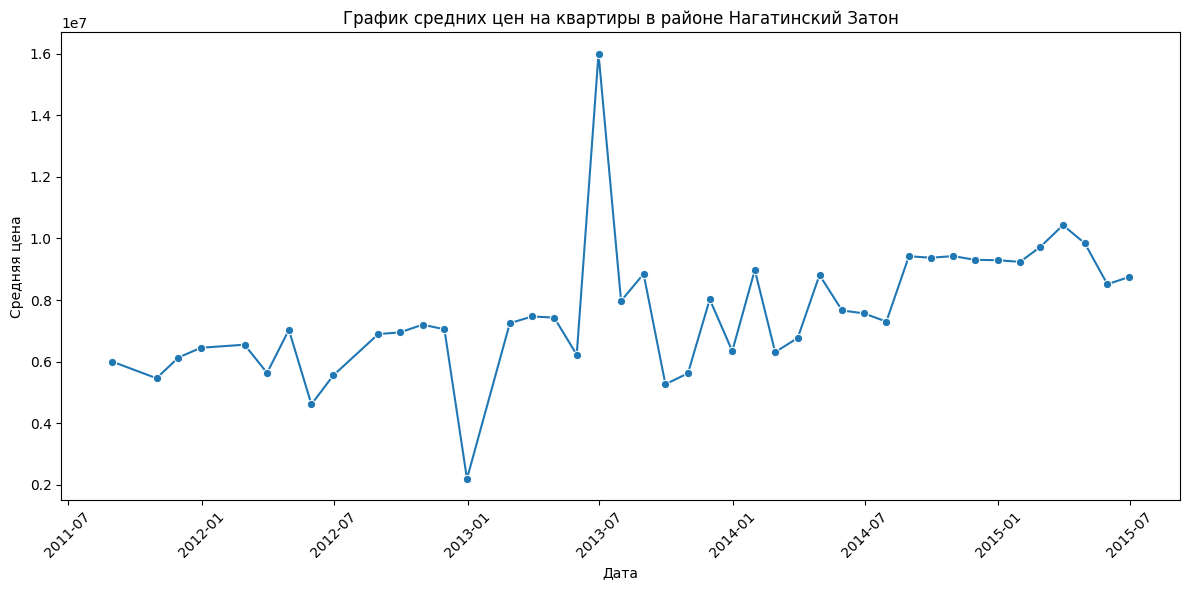

In [89]:
zaton_df = df[df['sub_area'] == 'Nagatinskij Zaton'].copy()
zaton_df['timestamp'] = pd.to_datetime(zaton_df['timestamp'])
monthly_avg_price = zaton_df.groupby(pd.Grouper(key='timestamp', freq='ME'))['price_doc'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg_price, x='timestamp', y='price_doc', marker='o')
plt.title('График средних цен на квартиры в районе Нагатинский Затон')
plt.xlabel('Даты')
plt.ylabel('Средняя цена')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Постройте гистограмму распределения цен на квартиры с общей площадью более 50 кв.метров

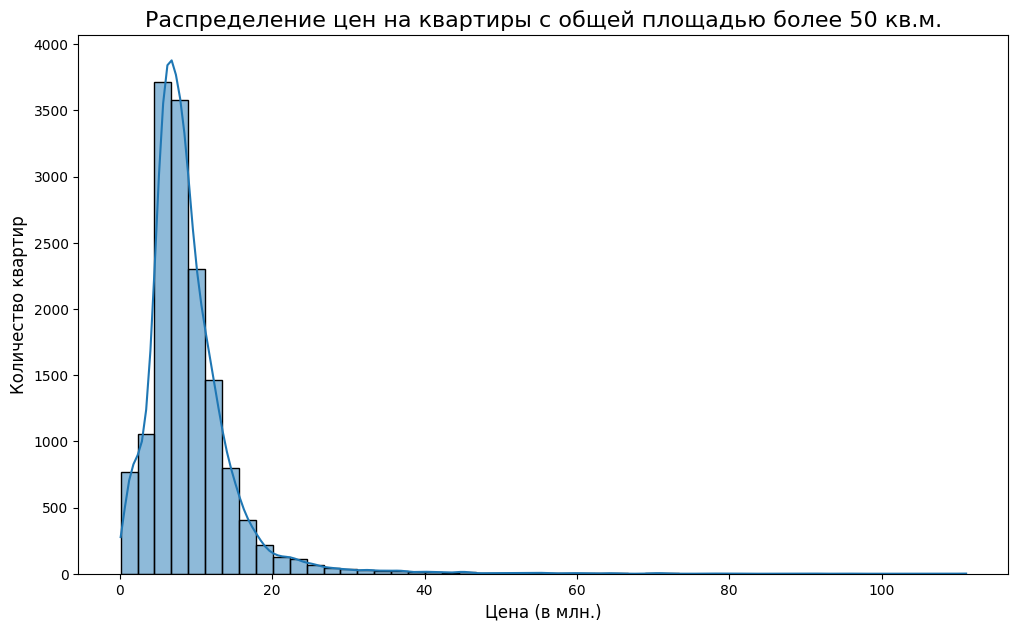

In [91]:
large_apartments_df = df[df['full_sq'] > 50].copy()
plt.figure(figsize=(12, 7))
sns.histplot(
    data=large_apartments_df,
    x='price_doc',
    kde=True,
    bins=50
)
plt.title('Распределение цен на квартиры с общей площадью более 50 кв.м.', fontsize=16)
plt.xlabel('Цена (в млн.)', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
formatter = plt.FuncFormatter(lambda x, pos: f'{x / 1_000_000:.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.show()

3. Визуализируйте количество проданных квартир в разных районах

In [95]:
all_areas_counts = df['sub_area'].value_counts().reset_index()
all_areas_counts.columns = ['sub_area', 'count']
all_areas_counts = all_areas_counts.sort_values(by='count', ascending=False)
fig = px.bar(
    all_areas_counts,
    x='sub_area',
    y='count',
    title='Количество проданных квартир в разных районах',
    labels={
        'sub_area': 'Район',
        'count': 'Количество квартир'
    },
    height=600
)
fig.update_xaxes(tickangle=90, showticklabels=False)

fig.show()

4. Постройте box plot отображающий распределение полных площадей квартир в Басманном районе

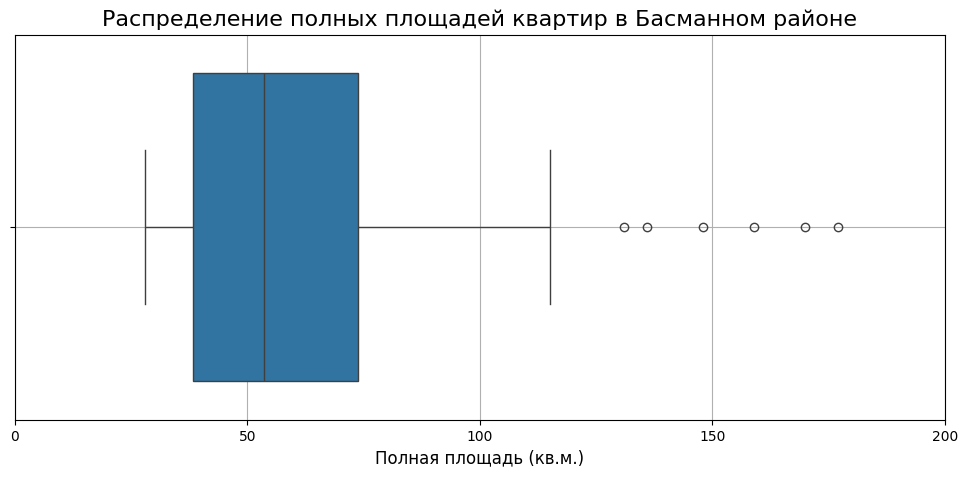

In [96]:
correct_district_name = 'Basmannoe'
basmanny_df = df[df['sub_area'] == correct_district_name].copy()
plt.figure(figsize=(12, 5))
sns.boxplot(data=basmanny_df, x='full_sq', orient='h')
plt.title('Распределение полных площадей квартир в Басманном районе', fontsize=16)
plt.xlabel('Полная площадь (кв.м.)', fontsize=12)
plt.ylabel('')
plt.xticks(np.arange(0, basmanny_df['full_sq'].max() + 50, 50))
plt.grid(True)
plt.show()

5. Визуализируйте зависимость средней стоимости квартир в зависимости от этажа

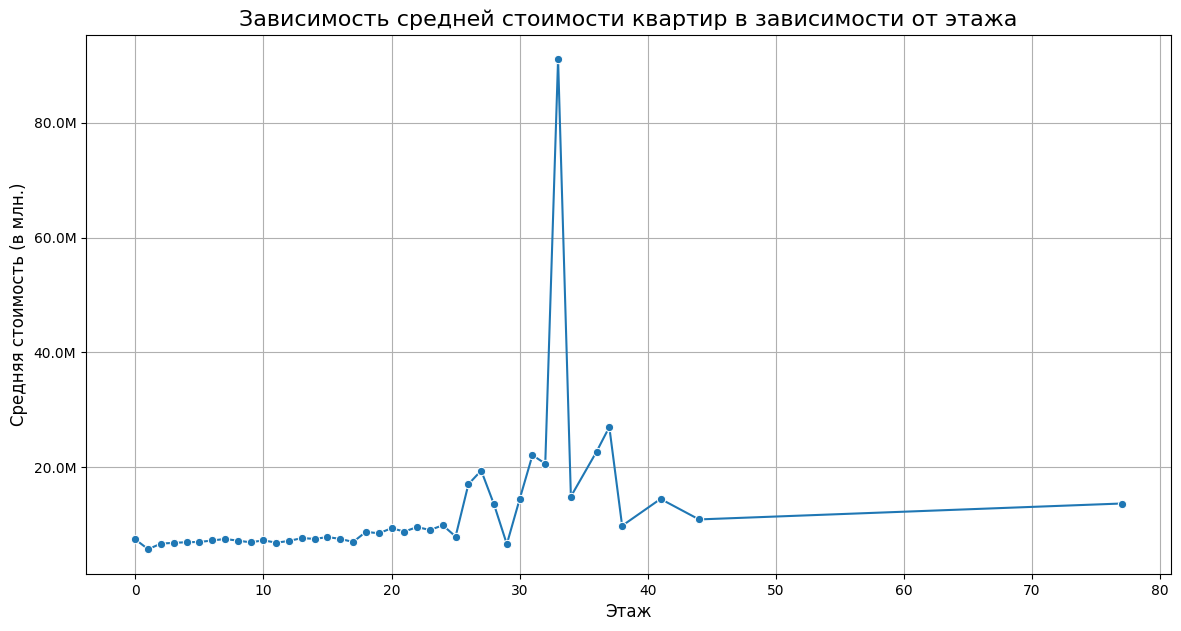

In [98]:
avg_price_by_floor = df.groupby('floor')['price_doc'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=avg_price_by_floor,
    x='floor',
    y='price_doc',
    marker='o'
 )

plt.title('Зависимость средней стоимости квартир в зависимости от этажа', fontsize=16)
plt.xlabel('Этаж', fontsize=12)
plt.ylabel('Средняя стоимость (в млн.)', fontsize=12)

formatter = plt.FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True)
plt.show()

6. Покажите как меняется средняя площадь квартир в зависимости от района

In [100]:
avg_sq_by_area = df.groupby('sub_area')['full_sq'].mean().reset_index()
avg_sq_by_area = avg_sq_by_area.sort_values(by='full_sq', ascending=False)
fig = px.bar(
    avg_sq_by_area,
    x='sub_area',
    y='full_sq',
    title='Средняя площадь квартир в зависимости от района',
    labels={
        'sub_area': 'Район',
        'full_sq': 'Средняя полная площадь (кв.м.)'
    },
    height=600
)
fig.update_xaxes(showticklabels=False)
fig.update_traces(hovertemplate='Район: %{x}<br>Средняя площадь: %{y:.2f} кв.м.')
fig.show()

7. Постройте график изменения медианной цены на квартиру менее 50 кв. метров за период с 2011 до 2014 года*

\* Задание на доп. балл

In [102]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
mask = (
    (df['full_sq'] < 50) &
    (df['timestamp'].dt.year >= 2011) &
    (df['timestamp'].dt.year <= 2014)
)
small_apartments_df = df[mask].copy()
monthly_median_price = small_apartments_df.groupby(pd.Grouper(key='timestamp', freq='ME'))['price_doc'].median().reset_index()
fig = px.line(
    monthly_median_price,
    x='timestamp',
    y='price_doc',
    title='График изменения медианной цены на квартиры менее 50 кв.м. (2011-2014 гг.)',
    labels={
        'timestamp': 'Месяц',
        'price_doc': 'Медианная цена (в млн.)'
    },
    markers=True
)

fig.update_traces(hovertemplate='Дата: %{x|%Y-%m}<br>Медианная цена: %{y:,.0f}')
fig.update_layout(yaxis_title='Медианная цена', xaxis_title='Дата')

fig.show()